# 15. Blind self-counterfactual defense

## Строгая постановка

Метод получает одно изображение и не знает ни того, присутствует ли патч, ни его координат. Paired clean и истинный `patch_bbox` не входят в вычислительный путь. Истинный bbox ниже используется только после выбора окна — для оценки локализации.

Алгоритм делает coarse-to-fine поиск окон. Для каждого финалиста локальная область заменяется тремя способами (`gray`, `context_mean`, `blur`). Окно оценивается по согласованному восстановлению person-score одного и того же кандидата. После выбора окна строится proxy→observed joint score+geometry functional component и удаляется из Detect-input activations.

Поскольку поиск всегда найдёт лучшее окно даже на clean, решение о вмешательстве принимает one-class gate. Все его параметры и порог вычисляются только на 50 calibration-clean изображениях; ещё 50 clean используются как test. Attack labels в калибровке не участвуют.

Это **blind/no-clean gray-box**, а не output-only black box: методу доступны внутренние активации и градиенты модели.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
ROOT = Path.cwd()
if ROOT.name != 'CandidateRoutingAndAttackPath': ROOT = ROOT / 'CandidateRoutingAndAttackPath'
candidates = []
for d in (ROOT/'followup_outputs').glob('self_counterfactual_*'):
    if not (d/'summary.json').exists(): continue
    s = json.loads((d/'summary.json').read_text())
    if s['config'].get('blind_search', False): candidates.append((d, s))
RUN, SUMMARY = max(candidates, key=lambda z: z[1]['config'].get('method_version', 0))
X = pd.read_csv(RUN/'self_counterfactual_rows.csv')
G = pd.read_csv(RUN/'gate_decisions.csv')
P = X[X.input_kind.eq('patched')]
H = P[P.source_hidden.eq(1)]
C = X[X.input_kind.eq('clean')]
print(RUN.name, '| elapsed:', round(SUMMARY['elapsed_seconds']/60, 2), 'min | examples:', len(P))

self_counterfactual_ff827f52d294a456 | elapsed: 7.02 min | examples: 100


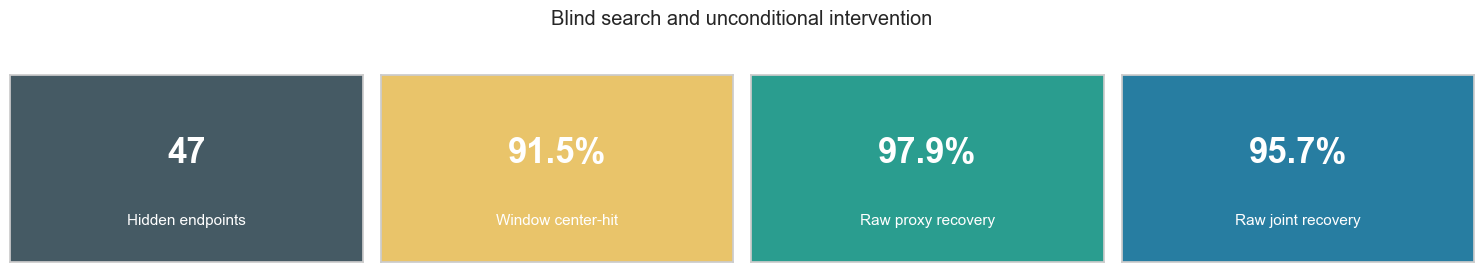

In [2]:
cards = [
 ('Hidden endpoints', len(H), '#455a64'),
 ('Window center-hit', H.search_center_hit.mean(), '#e9c46a'),
 ('Raw proxy recovery', H.proxy_view_target_detected.mean(), '#2a9d8f'),
 ('Raw joint recovery', H.joint_repair_target_detected.mean(), '#277da1'),
]
fig, axes = plt.subplots(1,4,figsize=(15,2.6))
for ax,(label,value,color) in zip(axes,cards):
    ax.set_facecolor(color); shown = str(value) if isinstance(value,int) else f'{value:.1%}'
    ax.text(.5,.58,shown,ha='center',va='center',fontsize=25,color='white',weight='bold')
    ax.text(.5,.22,label,ha='center',va='center',fontsize=11,color='white'); ax.set(xticks=[],yticks=[])
plt.suptitle('Blind search and unconditional intervention', y=1.04); plt.tight_layout(); plt.show()

**Что видно.** Без clean и bbox blind-поиск выбирает окно, содержащее центр истинного патча, в 43/47 скрытых случаях. Если безусловно применить выбранное вмешательство, proxy-маскировка восстанавливает 46/47 целей, малая joint-компонента — 45/47. Следовательно, изображение само содержит достаточно контрфактического сигнала для восстановления target. Но безусловное применение ещё не является защитой: чистый вход также порождает «лучшее» окно.

,coverage_bin,n,proxy_recovery,joint_recovery,proxy_f1,joint_f1
0,0,4,0.75,0.5,0.290,0.162
1,"(0,.5]",21,1.00,1.0,0.745,0.352
2,"(.5,.75]",11,1.00,1.0,0.678,0.369
3,"(.75,1]",11,1.00,1.0,0.904,0.269


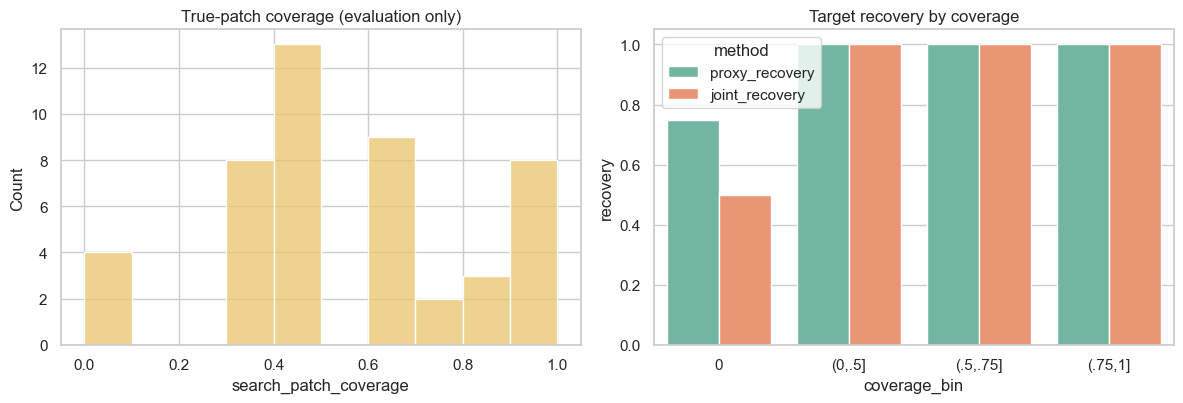

In [3]:
bins = pd.cut(H.search_patch_coverage, [-.01,.01,.5,.75,1.01], labels=['0','(0,.5]','(.5,.75]','(.75,1]'])
by_cov = H.assign(coverage_bin=bins).groupby('coverage_bin', observed=False).agg(
    n=('example_id','size'), proxy_recovery=('proxy_view_target_detected','mean'),
    joint_recovery=('joint_repair_target_detected','mean'), proxy_f1=('proxy_view_detection_f1','mean'),
    joint_f1=('joint_repair_detection_f1','mean')).reset_index()
display(by_cov.round(3))
fig,axes=plt.subplots(1,2,figsize=(12,4.2))
sns.histplot(H.search_patch_coverage,bins=10,ax=axes[0],color='#e9c46a'); axes[0].set_title('True-patch coverage (evaluation only)')
plot=by_cov.melt(['coverage_bin','n'],value_vars=['proxy_recovery','joint_recovery'],var_name='method',value_name='recovery')
sns.barplot(data=plot,x='coverage_bin',y='recovery',hue='method',ax=axes[1],palette='Set2'); axes[1].set_ylim(0,1.05); axes[1].set_title('Target recovery by coverage')
plt.tight_layout(); plt.show()

**Что видно.** Точный bbox не требуется: при любом ненулевом перекрытии target восстанавливается во всех 43 случаях. Среди четырёх промахов proxy восстанавливает три target, joint correction — два, поэтому эффект определяется не только геометрическим совпадением окна. Тем не менее текущий датасет содержит патч в одной фиксированной позиции; перенос локализации на другие положения этим экспериментом ещё не доказан.

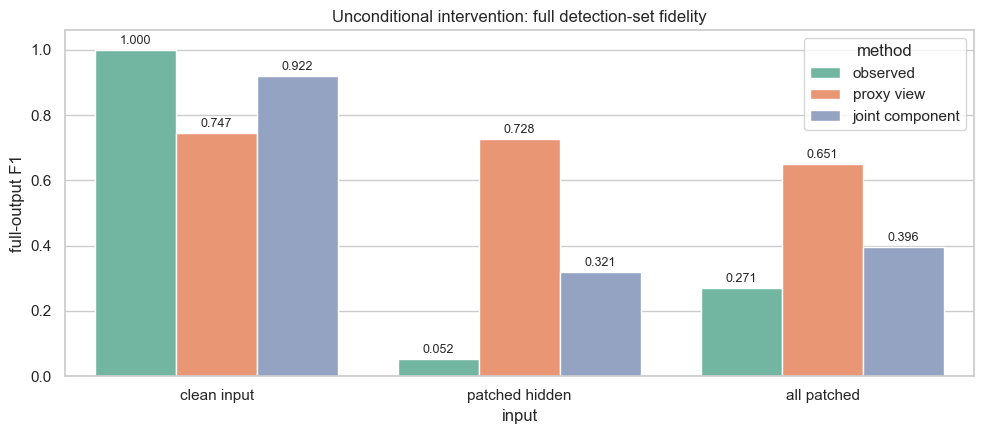

input,all patched,clean input,patched hidden
method,,,
joint component,0.3962,0.9217,0.3208
observed,0.2712,1.0000,0.0522
proxy view,0.6509,0.7470,0.7278


In [4]:
conditions={'observed':'observed_detection_f1','proxy view':'proxy_view_detection_f1','joint component':'joint_repair_detection_f1'}
records=[]
for subset_name,df in [('clean input',C),('patched hidden',H),('all patched',P)]:
    for method,col in conditions.items(): records.append({'input':subset_name,'method':method,'full-output F1':df[col].mean()})
fidelity=pd.DataFrame(records)
plt.figure(figsize=(10,4.5)); ax=sns.barplot(data=fidelity,x='input',y='full-output F1',hue='method',palette='Set2')
for c in ax.containers: ax.bar_label(c,fmt='%.3f',padding=2,fontsize=9)
ax.set_ylim(0,1.06); plt.title('Unconditional intervention: full detection-set fidelity'); plt.tight_layout(); plt.show()
display(fidelity.pivot(index='method',columns='input',values='full-output F1').round(4))

**Что видно.** Blind proxy теряет качество относительно known-bbox proxy, но всё равно поднимает hidden full-output F1 с 0.052 до 0.728. Target-only joint correction снова чинит target, но не весь детектор (`F1=0.321`). На clean безусловная joint correction даёт `F1=0.922`, то есть слишком вредна для постоянного применения. Поэтому задача «найти полезную коррекцию» решена существенно лучше, чем задача «безопасно решить, когда её включить».

,gate,clean activation,hidden activation,hidden target recovery,joint patched F1,proxy patched F1
0,proxy_gain,0.04,0.1064,0.1064,0.2863,0.3135
1,repair_gain,0.06,0.1702,0.1702,0.2926,0.3329
2,conservative_gain,0.08,0.1277,0.1277,0.2886,0.3241
3,self_consistency_anomaly,0.04,0.7660,0.7660,0.3743,0.5742


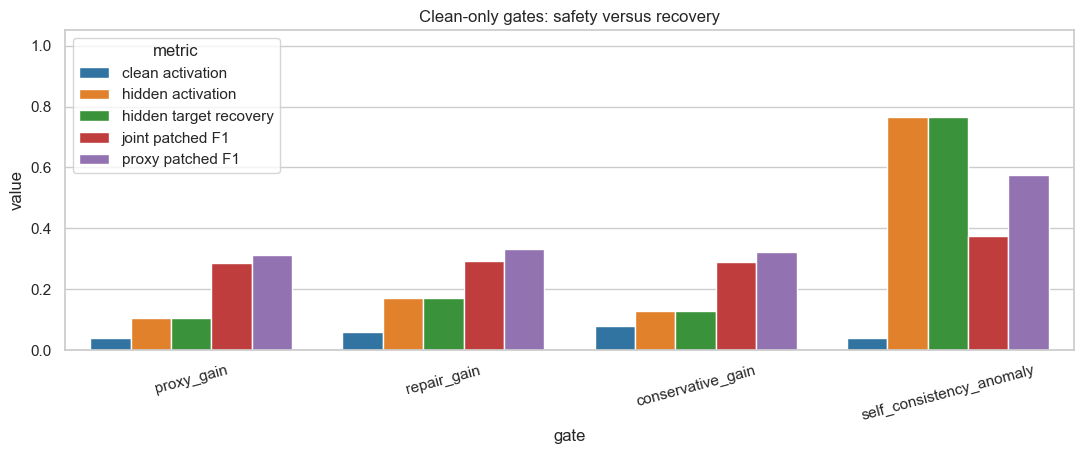

In [5]:
out=[]
for metric in G.gate_metric.unique():
    ct=G[(G.gate_metric.eq(metric))&(G.input_kind.eq('clean'))&(G.clean_split.eq('test'))]
    pa=G[(G.gate_metric.eq(metric))&(G.input_kind.eq('patched'))]
    ph=pa[pa.source_hidden.eq(1)]
    joint_f1=np.where(pa.gate_applied.astype(bool),pa.joint_repair_detection_f1,pa.observed_detection_f1)
    proxy_f1=np.where(pa.gate_applied.astype(bool),pa.proxy_view_detection_f1,pa.observed_detection_f1)
    out.append({'gate':metric,'clean activation':ct.gate_applied.mean(),'hidden activation':ph.gate_applied.mean(),
                'hidden target recovery':ph.defended_target_detected.mean(),'joint patched F1':joint_f1.mean(),'proxy patched F1':proxy_f1.mean()})
gates=pd.DataFrame(out); display(gates.round(4))
plot=gates.melt('gate',var_name='metric',value_name='value')
plt.figure(figsize=(11,4.7)); ax=sns.barplot(data=plot,x='gate',y='value',hue='metric',palette='tab10')
ax.set_ylim(0,1.05); ax.tick_params(axis='x',rotation=15); plt.title('Clean-only gates: safety versus recovery'); plt.tight_layout(); plt.show()

**Главный результат gate.** Одномерные пороги по gain слишком консервативны: при 4–8% clean activation они включают защиту лишь на 11–17% скрытых атак. У патча, однако, три преобразования дают почти одинаковый высокий score, а несколько соседних окон образуют плато. Поэтому clean-only `self_consistency_anomaly` объединяет высокий proxy score/repair gain с низкими variance между преобразованиями и margin между окнами. На независимых 50 clean-test он включается в 2/50 случаев (4%), а на hidden — в 36/47 (76.6%); все 36 target восстановлены. Gated joint сохраняет clean full-output F1 0.997, gated proxy — 0.990.

Это пока exploratory, а не финальная оценка: формула была предложена после просмотра этого cohort, clean test мал, а положение патча фиксировано. Следующий прогон должен заморозить формулу и проверить её на значительно большей независимой clean-выборке и атаках с разными положениями.

## Итог

- **Да:** без clean-примера и без знания bbox можно найти вмешательство, восстанавливающее target в 45/47 случаев.
- **Частично:** можно автоматически включить его и восстановить 36/47 атак при наблюдаемом clean activation 2/50.
- **Нет:** текущий target-only компонент ещё не восстанавливает полный output; для этого нужен global all-candidate functional repair.
- **Не доказано:** generalization на произвольные положения/размеры патча и надёжный false-positive rate на большой clean-выборке.

Следующий минимальный confirmatory эксперимент: заморозить blind search и `self_consistency_anomaly`, собрать независимые clean calibration/test и varied-location patched cohort, затем сравнить gated proxy, target-only component и global all-candidate component.